In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

EXPORTS = "outputs/dataset_exports"
EDA_DIR = "outputs/eda"
os.makedirs(EDA_DIR, exist_ok=True)

sns.set_theme(context="notebook", style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 140
plt.rcParams["figure.figsize"] = (8, 4.5)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

df = pd.read_csv(f"{EXPORTS}/clean_ege_dataset.csv")
df_long = pd.read_csv(f"{EXPORTS}/clean_ege_dataset_long.csv")
print("profiles:", df.shape, "  long:", df_long.shape)

profiles: (1413, 41)   long: (2092, 47)


## 1. Data overview

Quick structural summary so we know what we're working with.

In [2]:
print("PROFILE FILE — dtypes")
print(df.dtypes.value_counts())
print("\nfirst 3 rows (transposed):")
df.head(3).T

PROFILE FILE — dtypes
str        17
int64      14
float64     6
bool        4
Name: count, dtype: int64

first 3 rows (transposed):


                                                                                            0                                                  1  \
id                                                                                AbakumovPV4                                        AbalakinaNS   
name                                                                Абакумов Павел Васильевич                        Надежда Сергеевна Абалакина   
gender_raw                                                                               MALE                                             FEMALE   
gender_binary                                                                               0                                                  1   
reviews_count                                                                               2                                                 10   
rating_avg                                                                                5.0                   

In [3]:
# Numeric describe — saved to disk for the writeup.
num_describe = df.select_dtypes(include=[np.number]).describe().T
num_describe.to_csv(f"{EDA_DIR}/numeric_describe.csv")
num_describe

                        count         mean          std    min       25%     50%     75%      max
gender_binary          1413.0     0.508846     0.500099    0.0     0.000     1.0     1.0      1.0
reviews_count          1413.0    29.801132    46.214636    1.0     5.000    15.0    35.0    575.0
rating_avg             1413.0     4.951345     0.147641    2.0     4.950     5.0     5.0      5.0
reviews_1_count        1413.0     0.145081     0.508607    0.0     0.000     0.0     0.0      7.0
reviews_2_count        1413.0     0.133050     0.546030    0.0     0.000     0.0     0.0      6.0
reviews_3_count        1413.0     0.256192     0.905311    0.0     0.000     0.0     0.0     10.0
reviews_4_count        1413.0     0.791932     2.294350    0.0     0.000     0.0     0.0     24.0
reviews_5_count        1413.0    28.474876    43.723169    0.0     5.000    15.0    35.0    566.0
about_len              1413.0  1524.107573  1218.016392    0.0   775.000  1309.0  2001.0  19178.0
education_count     

## 2. Missingness

Two questions for the regression stage: which columns are missing enough to need imputation, and is the missingness MCAR/MAR/MNAR?

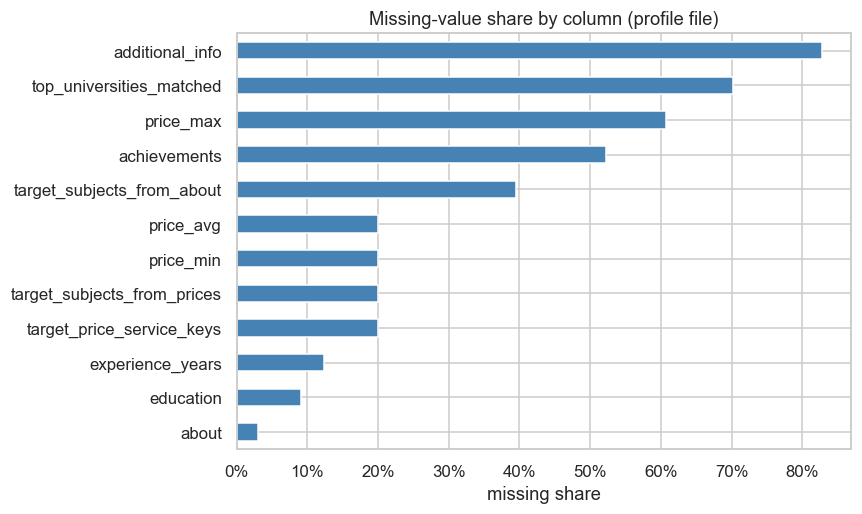

In [4]:
miss = df.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]
miss.to_csv(f"{EDA_DIR}/missing_share.csv", header=["share"])

fig, ax = plt.subplots(figsize=(8, 0.32 * len(miss) + 1))
miss.iloc[::-1].plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("missing share")
ax.set_title("Missing-value share by column (profile file)")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
fig.tight_layout()
fig.savefig(f"{EDA_DIR}/missing_share.png")
plt.show()

In [5]:
# Pricing missingness has a structural reason: ~20% of profiles have no priced ege subject.
# Confirm: every profile with NaN price_avg has price_subjects_count == 0.
no_price = df["price_avg"].isna()
assert (df.loc[no_price, "price_subjects_count"] == 0).all(), "unexpected NaN price for priced profile"
print(f"profiles without any priced subject: {no_price.sum()} ({no_price.mean():.1%})")

profiles without any priced subject: 283 (20.0%)


## 3. Univariate distributions

### 3a. Numeric — continuous regressors and price

Right-skew on price and reviews_count is expected; we'll need log transforms for the regression stage.

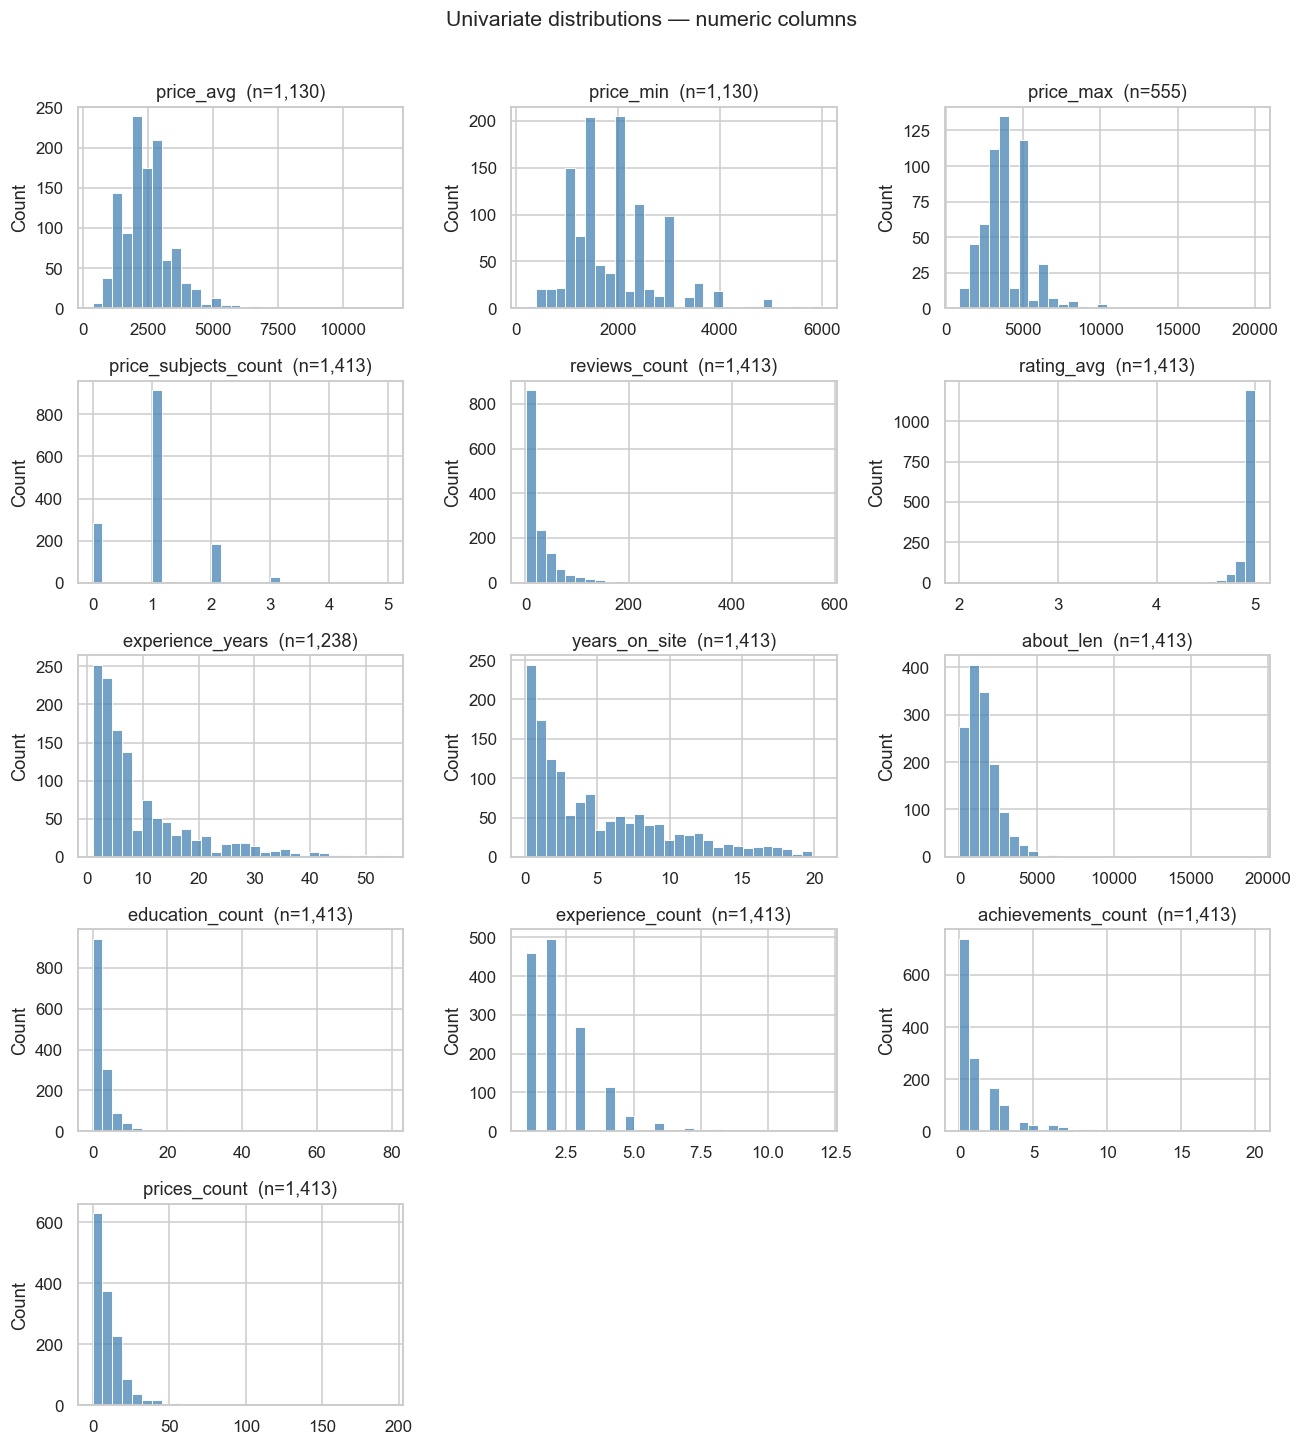

In [6]:
num_cols = [
    "price_avg", "price_min", "price_max", "price_subjects_count",
    "reviews_count", "rating_avg", "experience_years", "years_on_site",
    "about_len", "education_count", "experience_count", "achievements_count", "prices_count",
]
fig, axes = plt.subplots(5, 3, figsize=(12, 13))
for ax, col in zip(axes.flat, num_cols):
    s = df[col].dropna()
    sns.histplot(s, bins=30, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"{col}  (n={len(s):,})")
    ax.set_xlabel("")
for ax in axes.flat[len(num_cols):]:
    ax.set_visible(False)
fig.suptitle("Univariate distributions — numeric columns", y=1.01, fontsize=14)
fig.tight_layout()
fig.savefig(f"{EDA_DIR}/hist_numeric.png")
plt.show()

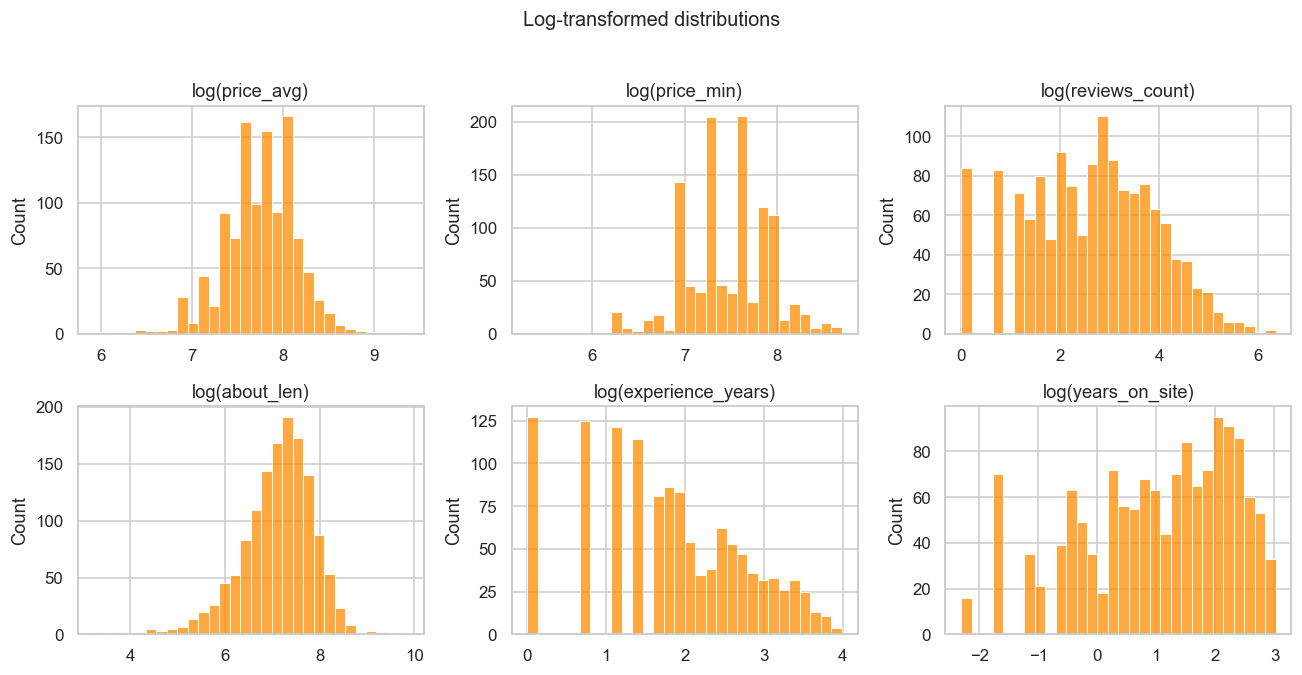

In [7]:
# Log-transformed view of right-skewed columns — what we'll feed to the regression.
log_cols = ["price_avg", "price_min", "reviews_count", "about_len", "experience_years", "years_on_site"]
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, col in zip(axes.flat, log_cols):
    s = df[col].dropna()
    s = s[s > 0]
    sns.histplot(np.log(s), bins=30, ax=ax, color="darkorange", edgecolor="white")
    ax.set_title(f"log({col})")
    ax.set_xlabel("")
fig.suptitle("Log-transformed distributions", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(f"{EDA_DIR}/hist_numeric_log.png")
plt.show()

In [8]:
# Skewness / kurtosis table to justify log transforms.
skew_tbl = pd.DataFrame({
    "skew_raw": df[num_cols].skew(),
    "kurt_raw": df[num_cols].kurt(),
    "skew_log": df[num_cols].apply(lambda s: np.log(s.dropna()[s.dropna() > 0]).skew()),
})
skew_tbl.to_csv(f"{EDA_DIR}/skewness.csv")
skew_tbl

                       skew_raw    kurt_raw   skew_log
price_avg              1.610221    8.411857  -0.335913
price_min              1.126875    2.021232  -0.347749
price_max              2.556264   19.854886  -0.108038
price_subjects_count   0.707837    2.113572   1.834873
reviews_count          4.470588   31.160759  -0.080321
rating_avg           -10.407438  162.246609 -14.416566
experience_years       1.770677    3.085006  -0.068195
years_on_site          1.054437    0.268147  -0.570890
about_len              3.899157   38.516805  -0.864697
education_count        8.740266  124.652899   0.916730
experience_count       1.603531    4.563229   0.187213
achievements_count     3.211011   14.969667   0.754491
prices_count           4.951689   51.002080  -0.258122

### 3b. Binary / categorical regressors

Variance check — flat columns won't help in the regression.

BINARY / CATEGORICAL VALUE COUNTS

  passport_verified  (non-null share: 100.0%)
passport_verified
True     1411
False       2

  remote_available  (non-null share: 100.0%)
remote_available
True     1397
False      16

  client_visit_available  (non-null share: 100.0%)
client_visit_available
False    976
True     437

  is_top_university  (non-null share: 100.0%)
is_top_university
False    992
True     421

  gender_raw  (non-null share: 100.0%)
gender_raw
FEMALE    719
MALE      694


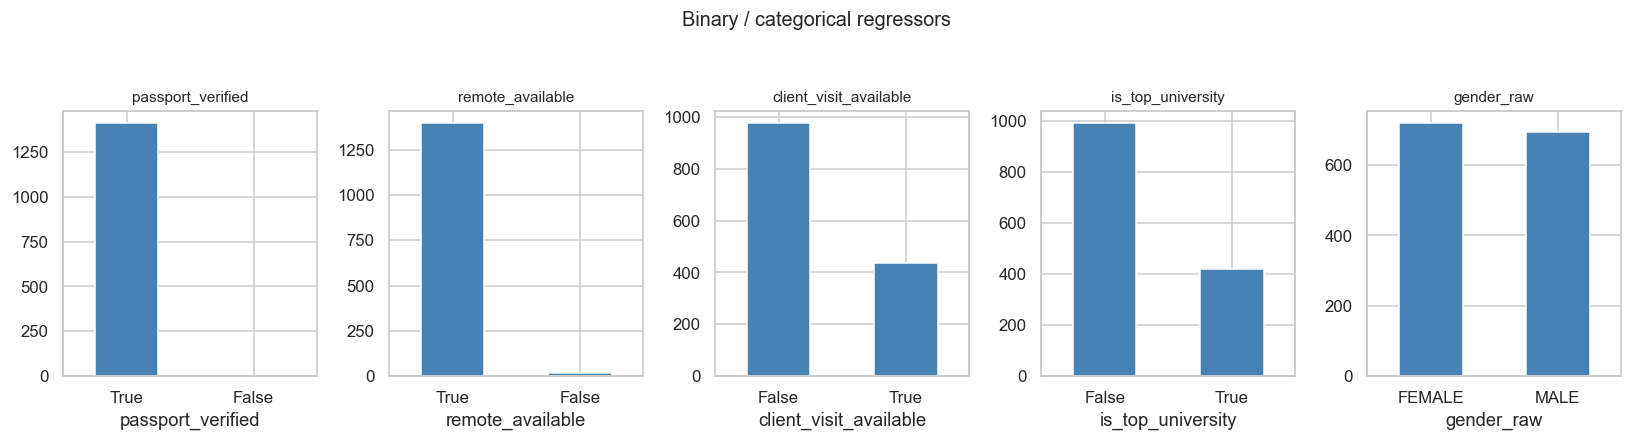

In [9]:
binary_cols = ["passport_verified", "remote_available", "client_visit_available", "is_top_university"]
cat_cols = ["gender_raw"]

print("BINARY / CATEGORICAL VALUE COUNTS")
for col in binary_cols + cat_cols:
    print(f"\n  {col}  (non-null share: {df[col].notna().mean():.1%})")
    print(df[col].value_counts(dropna=False).to_string())

fig, axes = plt.subplots(1, len(binary_cols + cat_cols), figsize=(15, 3.8))
for ax, col in zip(axes, binary_cols + cat_cols):
    vc = df[col].value_counts(dropna=False)
    vc.index = vc.index.astype(str)  # unify str for plotting (NaN → 'nan', True → 'True')
    vc.plot.bar(ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis="x", rotation=0)
fig.suptitle("Binary / categorical regressors", y=1.05, fontsize=13)
fig.tight_layout()
fig.savefig(f"{EDA_DIR}/cat_counts.png")
plt.show()

## 4. Subject-level analysis (long file)

Subject is the most important market segmentation. We need per-subject distributions before pooling.

In [10]:
subj_summary = df_long.groupby("subject").agg(
    n_offers=("id", "size"),
    n_tutors=("id", "nunique"),
    median_price=("subject_price_avg", "median"),
    mean_price=("subject_price_avg", "mean"),
    p25_price=("subject_price_avg", lambda s: s.quantile(0.25)),
    p75_price=("subject_price_avg", lambda s: s.quantile(0.75)),
).sort_values("n_offers", ascending=False)
subj_summary.to_csv(f"{EDA_DIR}/subject_summary.csv")
subj_summary

                 n_offers  n_tutors  median_price   mean_price  p25_price  p75_price
subject                                                                             
ege_math             1287       576        2500.0  2543.989899     2000.0     3000.0
ege_russian           254       254        2315.0  2433.877953     1700.0     2900.0
ege_english           206       206        2500.0  2442.548544     1950.0     3000.0
ege_physics           191       191        2500.0  2641.832461     2000.0     3000.0
ege_informatics       154       154        2500.0  2509.837662     1762.5     3000.0

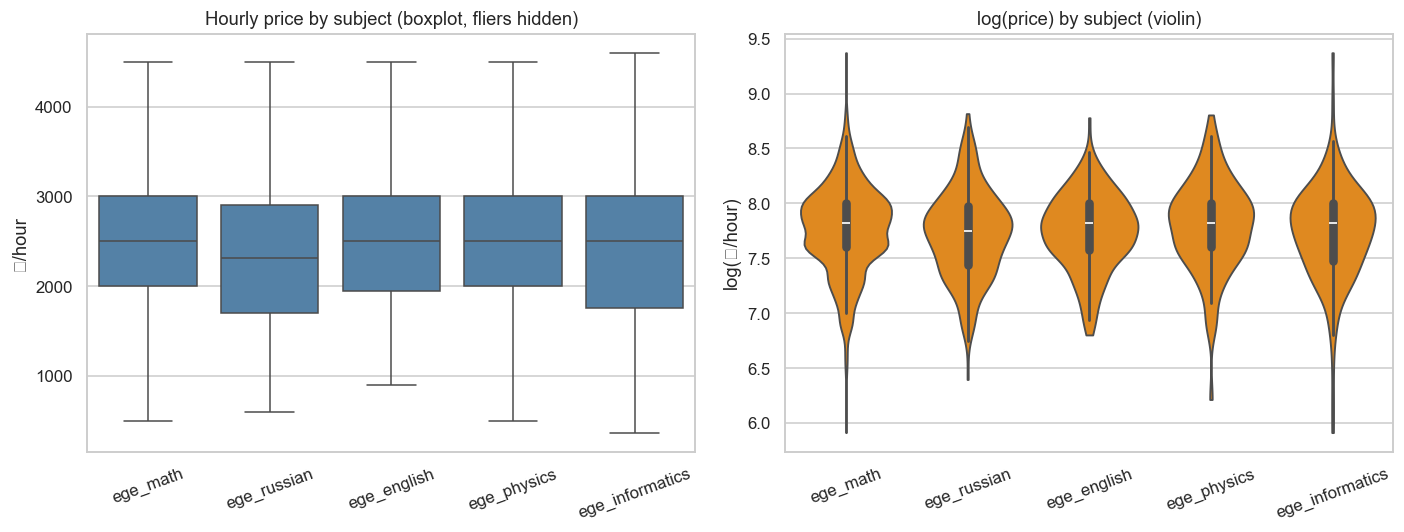

In [11]:
subj_order = subj_summary.index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(
    data=df_long, x="subject", y="subject_price_avg",
    order=subj_order, ax=axes[0], color="steelblue", showfliers=False,
)
axes[0].set_title("Hourly price by subject (boxplot, fliers hidden)")
axes[0].set_ylabel("₽/hour")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)

sns.violinplot(
    data=df_long.assign(log_price=np.log(df_long["subject_price_avg"])),
    x="subject", y="log_price", order=subj_order, ax=axes[1], color="darkorange", cut=0,
)
axes[1].set_title("log(price) by subject (violin)")
axes[1].set_xlabel("")
axes[1].set_ylabel("log(₽/hour)")
axes[1].tick_params(axis="x", rotation=20)

fig.tight_layout()
fig.savefig(f"{EDA_DIR}/price_by_subject.png")
plt.show()

In [12]:
# Are subject medians actually different? Kruskal–Wallis (non-parametric, robust to skew).
groups = [g["subject_price_avg"].dropna().values for _, g in df_long.groupby("subject")]
stat, p = stats.kruskal(*groups)
print(f"Kruskal–Wallis H={stat:.2f}, p={p:.2e}")
print("interpretation:", "reject H0 — subject medians differ" if p < 0.01 else "cannot reject H0")

Kruskal–Wallis H=6.94, p=1.39e-01
interpretation: cannot reject H0


## 5. Price vs continuous regressors

Scatter + LOWESS for shape. We're checking functional form (linear vs log-log) and looking for non-linearities (e.g. diminishing returns to experience).

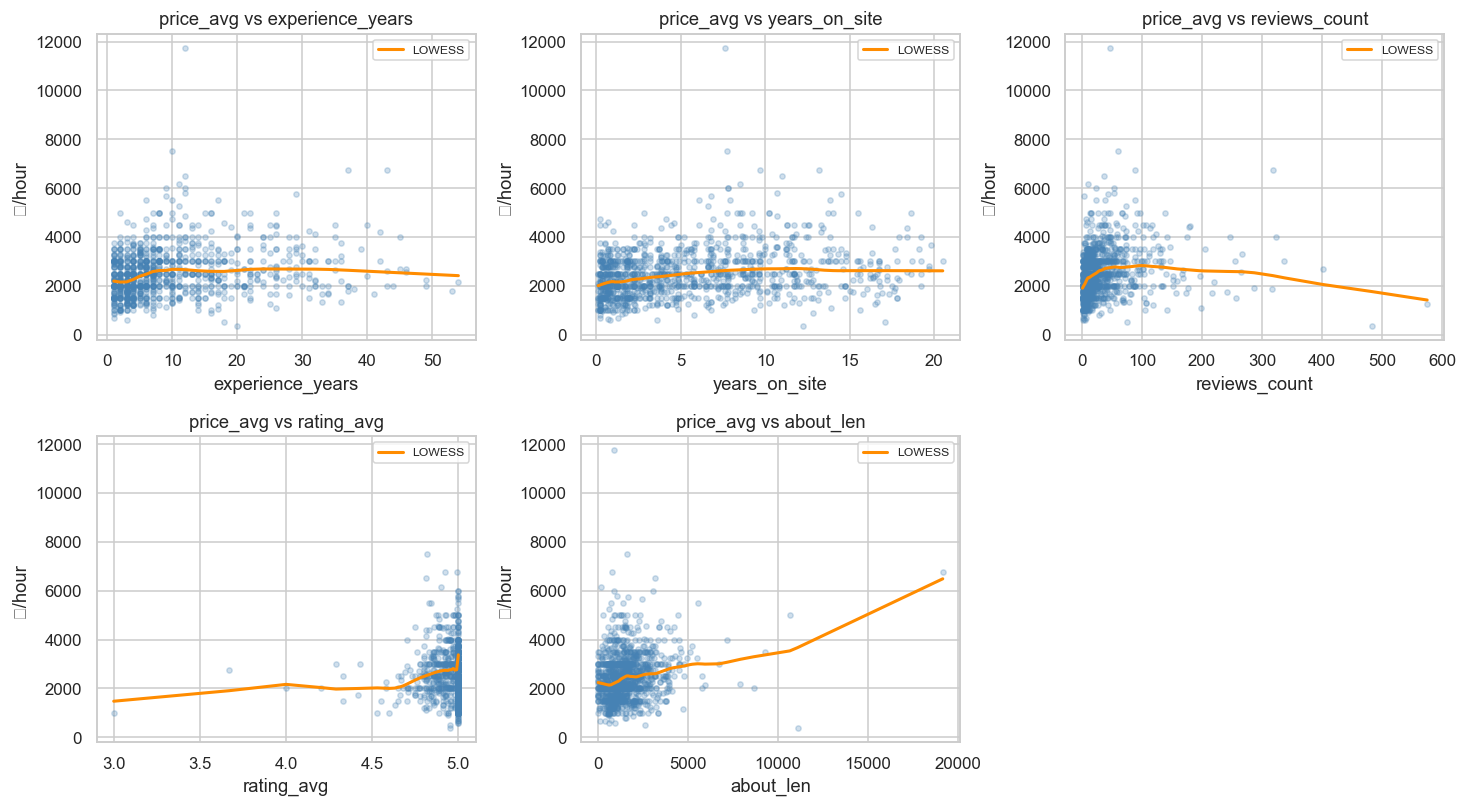

In [13]:
from statsmodels.nonparametric.smoothers_lowess import lowess

cont_regressors = ["experience_years", "years_on_site", "reviews_count", "rating_avg", "about_len"]
fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.5))
for ax, col in zip(axes.flat, cont_regressors):
    d = df[["price_avg", col]].dropna()
    d = d[d["price_avg"] > 0]
    ax.scatter(d[col], d["price_avg"], alpha=0.25, s=12, color="steelblue")
    sm_line = lowess(d["price_avg"], d[col], frac=0.3, return_sorted=True)
    ax.plot(sm_line[:, 0], sm_line[:, 1], color="darkorange", lw=2, label="LOWESS")
    ax.set_xlabel(col)
    ax.set_ylabel("₽/hour")
    ax.set_title(f"price_avg vs {col}")
    ax.legend(loc="upper right", fontsize=8)
for ax in axes.flat[len(cont_regressors):]:
    ax.set_visible(False)
fig.tight_layout()
fig.savefig(f"{EDA_DIR}/scatter_price_vs_continuous.png")
plt.show()

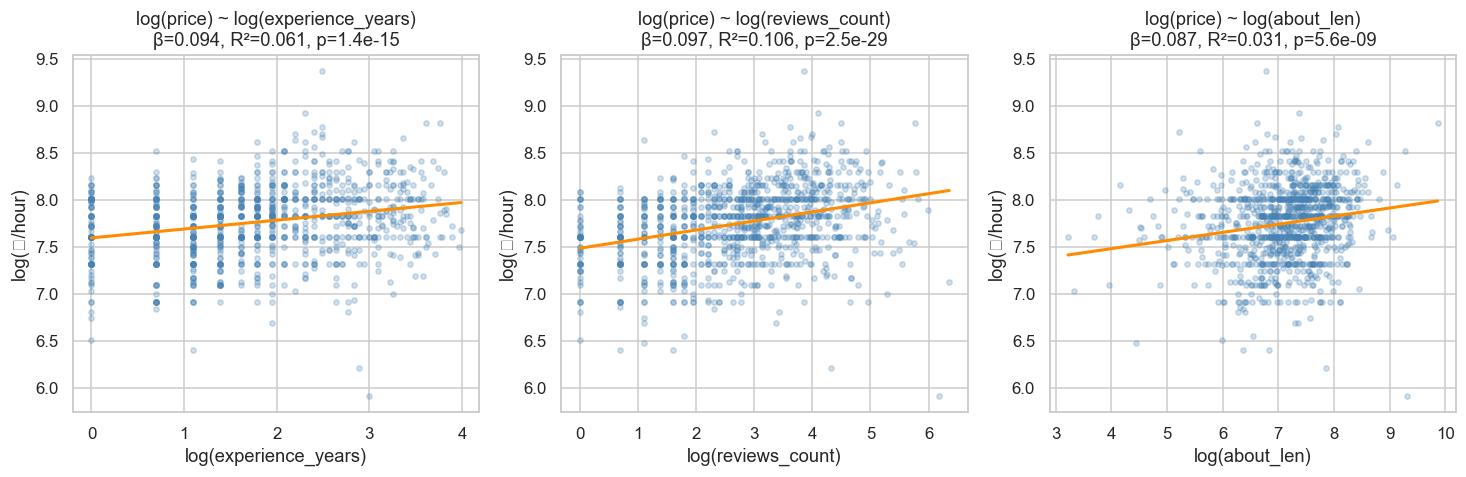

In [14]:
# log-log views for the right-skewed regressors — slope ≈ elasticity.
ll_pairs = [("experience_years", True), ("reviews_count", True), ("about_len", True)]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.5))
for ax, (col, _) in zip(axes, ll_pairs):
    d = df[["price_avg", col]].dropna()
    d = d[(d["price_avg"] > 0) & (d[col] > 0)]
    x = np.log(d[col])
    y = np.log(d["price_avg"])
    ax.scatter(x, y, alpha=0.25, s=12, color="steelblue")
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, intercept + slope * xs, color="darkorange", lw=2)
    ax.set_title(f"log(price) ~ log({col})\nβ={slope:.3f}, R²={r**2:.3f}, p={p:.1e}")
    ax.set_xlabel(f"log({col})")
    ax.set_ylabel("log(₽/hour)")
fig.tight_layout()
fig.savefig(f"{EDA_DIR}/loglog_price_vs_continuous.png")
plt.show()

## 6. Price vs binary regressors

Group means + non-parametric tests. Magnitudes will inform expected coefficients in the regression.

In [15]:
binary_regressors = ["passport_verified", "remote_available", "client_visit_available", "is_top_university"]
rows = []
for col in binary_regressors:
    d = df[["price_avg", col]].dropna()
    yes = d.loc[d[col] == True, "price_avg"]
    no = d.loc[d[col] == False, "price_avg"]
    if len(yes) < 10 or len(no) < 10:
        continue
    u, p = stats.mannwhitneyu(yes, no, alternative="two-sided")
    rows.append({
        "feature": col,
        "n_true": len(yes), "n_false": len(no),
        "median_true": yes.median(), "median_false": no.median(),
        "mean_true": yes.mean(), "mean_false": no.mean(),
        "diff_pct": (yes.median() - no.median()) / no.median() * 100,
        "mwu_p": p,
    })
binary_tbl = pd.DataFrame(rows).set_index("feature").round(3)
binary_tbl.to_csv(f"{EDA_DIR}/price_by_binary.csv")
binary_tbl

                        n_true  n_false  median_true  median_false  mean_true  mean_false  diff_pct  mwu_p
feature                                                                                                   
remote_available          1119       11       2500.0        2500.0   2498.308    2233.636     0.000  0.503
client_visit_available     362      768       2500.0        2330.0   2618.424    2437.899     7.296  0.002
is_top_university          341      789       2500.0        2400.0   2531.610    2480.225     4.167  0.305

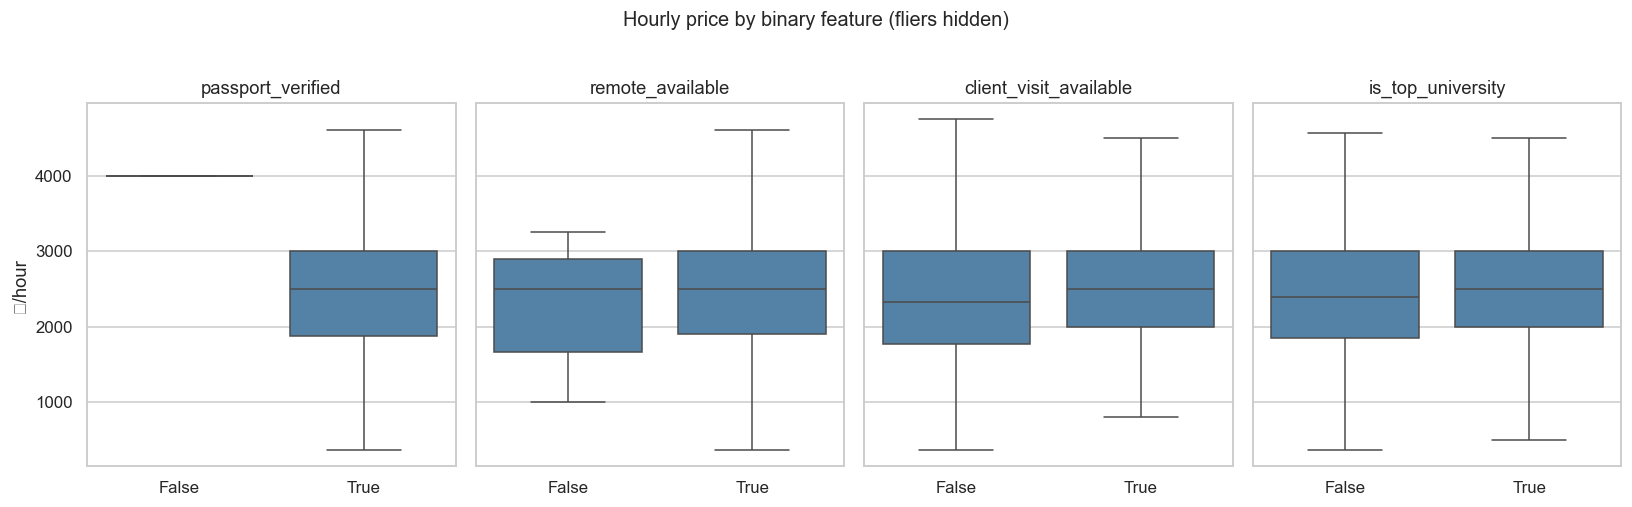

In [16]:
fig, axes = plt.subplots(1, len(binary_regressors), figsize=(15, 4.5), sharey=True)
for ax, col in zip(axes, binary_regressors):
    d = df[["price_avg", col]].dropna()
    sns.boxplot(data=d, x=col, y="price_avg", ax=ax, color="steelblue", showfliers=False)
    ax.set_title(col)
    ax.set_xlabel("")
axes[0].set_ylabel("₽/hour")
fig.suptitle("Hourly price by binary feature (fliers hidden)", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(f"{EDA_DIR}/price_by_binary.png")
plt.show()

In [17]:
# Gender deserves its own look — three categories incl. NaN.
g = df.dropna(subset=["gender_raw", "price_avg"])
print(g.groupby("gender_raw")["price_avg"].agg(["count", "mean", "median", "std"]).round(0))
fem = g.loc[g["gender_raw"] == "FEMALE", "price_avg"]
mal = g.loc[g["gender_raw"] == "MALE", "price_avg"]
u, p = stats.mannwhitneyu(fem, mal, alternative="two-sided")
print(f"\nMann–Whitney U (female vs male): U={u:.0f}, p={p:.2e}")
print(f"median gap: {(mal.median() - fem.median()):.0f} ₽ ({(mal.median()/fem.median() - 1)*100:.1f}% premium for males)")

            count    mean  median     std
gender_raw                               
FEMALE        600  2496.0  2500.0   929.0
MALE          530  2496.0  2500.0  1035.0

Mann–Whitney U (female vs male): U=159998, p=8.55e-01
median gap: 0 ₽ (0.0% premium for males)


## 7. Correlation structure

Spearman correlations on the regressors we'll use. Goal: spot multicollinearity (|ρ| > 0.7) before fitting.

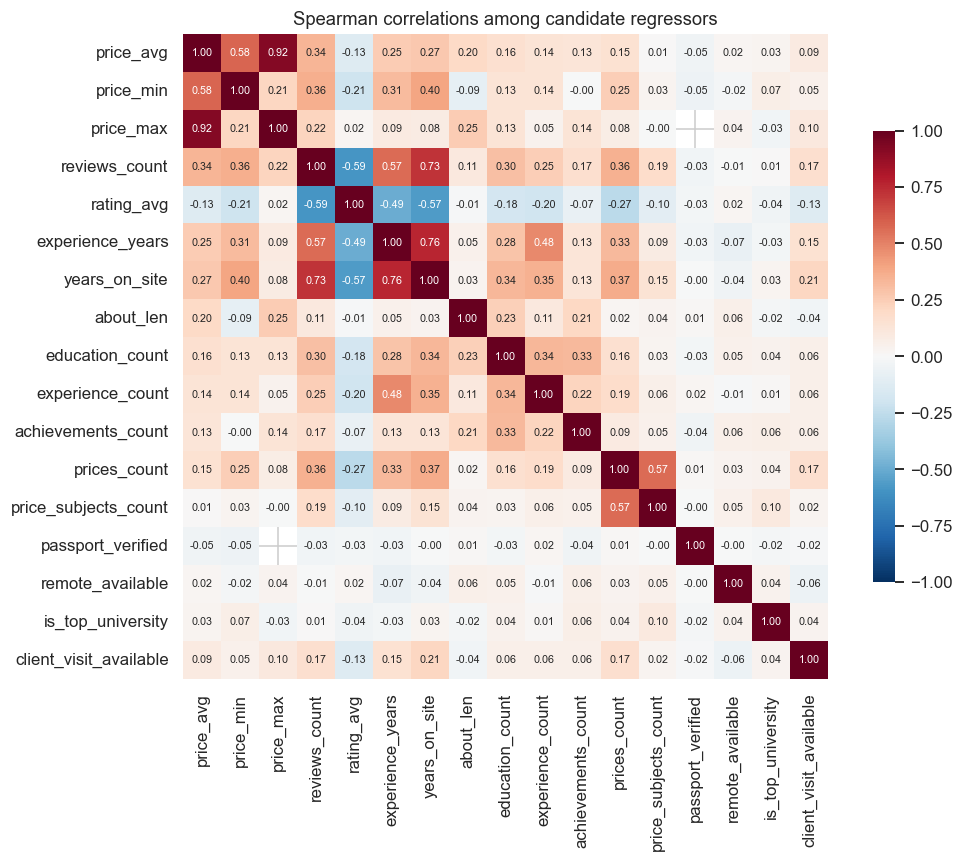

In [18]:
corr_cols = [
    "price_avg", "price_min", "price_max",
    "reviews_count", "rating_avg", "experience_years", "years_on_site",
    "about_len", "education_count", "experience_count", "achievements_count",
    "prices_count", "price_subjects_count",
    "passport_verified", "remote_available", "is_top_university", "client_visit_available",
]
# Cast booleans → ints so they enter the correlation matrix.
corr_df = df[corr_cols].copy()
for c in corr_df.select_dtypes(include=["boolean", "object"]).columns:
    corr_df[c] = corr_df[c].astype("float")
rho = corr_df.corr(method="spearman")
rho.to_csv(f"{EDA_DIR}/spearman_corr.csv")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    rho, annot=True, fmt=".2f", center=0, cmap="RdBu_r", vmin=-1, vmax=1,
    annot_kws={"size": 7}, square=True, ax=ax, cbar_kws={"shrink": 0.7},
)
ax.set_title("Spearman correlations among candidate regressors")
fig.tight_layout()
fig.savefig(f"{EDA_DIR}/spearman_corr.png")
plt.show()

In [19]:
# Flag pairs above the multicollinearity threshold.
thr = 0.7
pairs = (
    rho.where(np.triu(np.ones_like(rho), k=1).astype(bool))
    .stack()
    .pipe(lambda s: s[s.abs() > thr])
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
print(f"pairs with |ρ| > {thr}:")
print(pairs.to_string() if len(pairs) else "  (none)")

pairs with |ρ| > 0.7:
price_avg         price_max        0.920834
experience_years  years_on_site    0.760726
reviews_count     years_on_site    0.726072


## 8. Within-profile pricing structure

How much do tutors price-discriminate across subjects? Subject premia tell us where market thickness or scarcity sits.

profiles with ≥2 priced subjects: 216 (15.3%)

price_spread describe:
count      216.0
mean      1101.0
std       1722.0
min          0.0
25%          0.0
50%        372.0
75%       1700.0
max      16500.0
Name: price_spread, dtype: float64


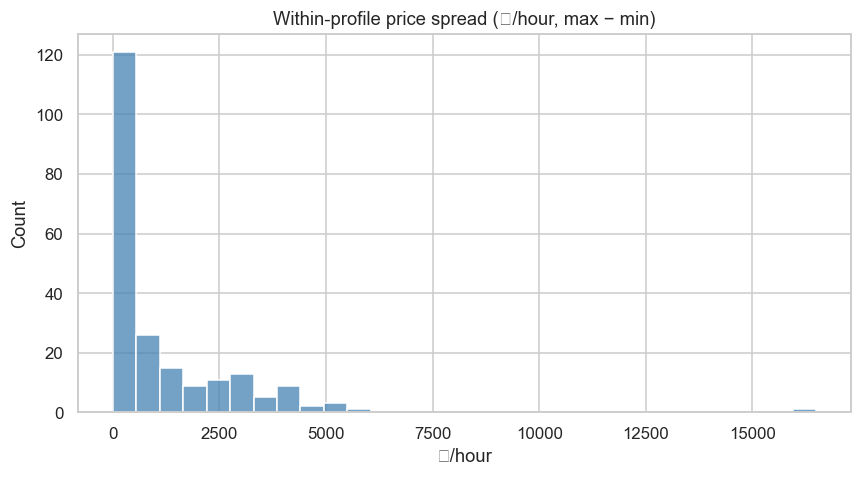

In [20]:
# Spread within profile (only meaningful when at least 2 priced subjects).
multi = df[df["price_subjects_count"] >= 2].copy()
multi["price_spread"] = multi["price_max"].fillna(multi["price_avg"]) - multi["price_min"]
print(f"profiles with ≥2 priced subjects: {len(multi)} ({len(multi)/len(df):.1%})")
print("\nprice_spread describe:")
print(multi["price_spread"].describe().round(0))

fig, ax = plt.subplots()
sns.histplot(multi["price_spread"], bins=30, ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Within-profile price spread (₽/hour, max − min)")
ax.set_xlabel("₽/hour")
fig.tight_layout()
fig.savefig(f"{EDA_DIR}/within_profile_spread.png")
plt.show()

                 count  mean  median
subject                             
ege_math          1287  -0.3     0.0
ege_russian        254  -3.1     0.0
ege_english        206   3.1     0.0
ege_physics        191   2.4     0.0
ege_informatics    154   0.6     0.0


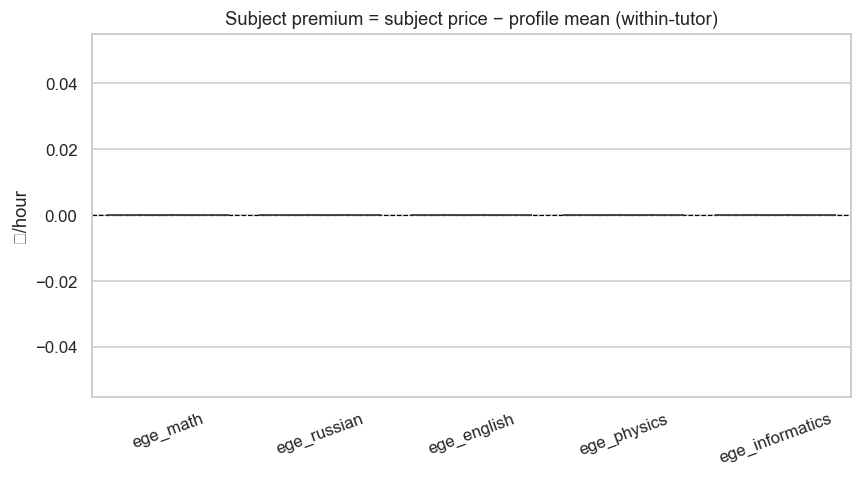

In [21]:
# Subject premium: subject_price_avg − profile-level price_avg, computed in the long file.
df_long["subject_premium"] = df_long["subject_price_avg"] - df_long["price_avg"]
premium = df_long.groupby("subject")["subject_premium"].agg(["count", "mean", "median"]).round(1)
premium = premium.loc[subj_order]
premium.to_csv(f"{EDA_DIR}/subject_premium.csv")
print(premium)

fig, ax = plt.subplots()
sns.boxplot(
    data=df_long, x="subject", y="subject_premium",
    order=subj_order, ax=ax, color="steelblue", showfliers=False,
)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_title("Subject premium = subject price − profile mean (within-tutor)")
ax.set_ylabel("₽/hour")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(f"{EDA_DIR}/subject_premium.png")
plt.show()

## 9. Summary findings

Compact memo for the regression stage. Quantitative numbers are pulled live from the cells above so they stay in sync.

In [22]:
lines = []
lines.append(f"Sample: {len(df):,} active EGE tutors (≥1 review in last 6 months) and {len(df_long):,} (tutor, subject) pairs.")
lines.append("")
lines.append("PRICING")
lines.append(f"  • Hourly price (price_avg): median {df['price_avg'].median():.0f} ₽, p25 {df['price_avg'].quantile(.25):.0f}, p75 {df['price_avg'].quantile(.75):.0f}, max {df['price_avg'].max():.0f}")
lines.append(f"  • Right-skewed (skew_raw={df['price_avg'].skew():.2f} → log_skew={np.log(df['price_avg'].dropna()).skew():.2f}). Use log price for regression.")
lines.append(f"  • {no_price.sum()} ({no_price.mean():.1%}) tutors have no priced subject — drop or impute for the regression stage.")
lines.append("")
lines.append("SUBJECT MIX")
for subj, row in subj_summary.iterrows():
    lines.append(f"  • {subj:18s} n={int(row['n_offers']):>4}  median={row['median_price']:.0f} ₽")
kw_verdict = (
    "subject FEs are needed (subject medians differ)"
    if p < 0.05
    else "cannot reject equality of subject medians — subject FEs may not move the needle in this active-tutor subset"
)
lines.append(f"  • Kruskal–Wallis on subject prices: p={p:.2e} → {kw_verdict}")
lines.append("")
lines.append("BINARY EFFECTS (Mann–Whitney U on price_avg)")
for f, row in binary_tbl.iterrows():
    sig = "*" if row["mwu_p"] < 0.05 else " "
    lines.append(f"  {sig} {f:25s} median_true={row['median_true']:.0f}  median_false={row['median_false']:.0f}  Δ={row['diff_pct']:+.1f}%  p={row['mwu_p']:.2e}")
lines.append("")
lines.append("LOW-VARIANCE BINARIES (drop from regression — share of dominant class)")
for col in binary_cols:
    share = df[col].value_counts(normalize=True).max()
    if share > 0.95:
        lines.append(f"  • {col}: dominant class = {share:.1%}")
lines.append("")
lines.append("MULTICOLLINEARITY (|ρ| > 0.7 — pick one from each pair)")
if len(pairs):
    for (a, b), v in pairs.items():
        lines.append(f"  • {a} ↔ {b}: ρ={v:.2f}")
else:
    lines.append("  • No pairs above threshold.")

memo = "\n".join(lines)
print(memo)
with open(f"{EDA_DIR}/summary.txt", "w") as f:
    f.write(memo)

Sample: 1,413 active EGE tutors (≥1 review in last 6 months) and 2,092 (tutor, subject) pairs.

PRICING
  • Hourly price (price_avg): median 2500 ₽, p25 1884, p75 3000, max 11750
  • Right-skewed (skew_raw=1.61 → log_skew=-0.34). Use log price for regression.
  • 283 (20.0%) tutors have no priced subject — drop or impute for the regression stage.

SUBJECT MIX
  • ege_math           n=1287  median=2500 ₽
  • ege_russian        n= 254  median=2315 ₽
  • ege_english        n= 206  median=2500 ₽
  • ege_physics        n= 191  median=2500 ₽
  • ege_informatics    n= 154  median=2500 ₽
  • Kruskal–Wallis on subject prices: p=8.55e-01 → cannot reject equality of subject medians — subject FEs may not move the needle in this active-tutor subset

BINARY EFFECTS (Mann–Whitney U on price_avg)
    remote_available          median_true=2500  median_false=2500  Δ=+0.0%  p=5.03e-01
  * client_visit_available    median_true=2500  median_false=2330  Δ=+7.3%  p=2.00e-03
    is_top_university         medi